In [1]:
# 1. Import Packages
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
# 2. Import Player Data
url_player = 'https://raw.githubusercontent.com/jpelayo35/CPSC5071_DSP/refs/heads/main/playerdata.csv'
player = pd.read_csv(url_player)

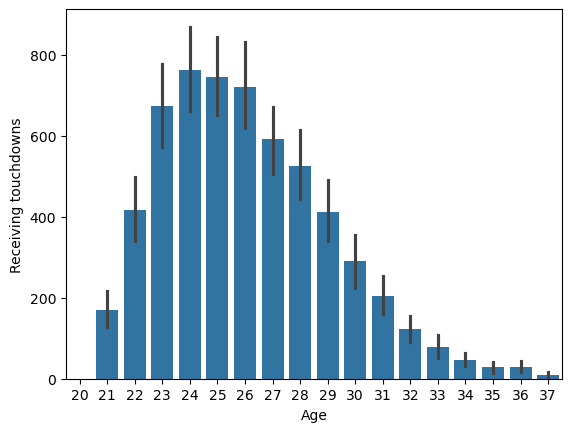

In [3]:
# Create variable for Age between 23-29
player['Age2229'] = (player['age'] >= 22) & (player['age'] <= 29)
player['Age2229'] = player['Age2229'].astype(int)

In [8]:
# Create the initial model to use seasons 2013-2022, to predict 2023

# 3. Define the features and target
X_coef=['receiving_yards', 'depth', 'Age2229']
Y_coef='reception_td'
# 4. Split into training and testing sets
X_train=player[player['season'] !=2023]
X_train=X_train[X_coef]

X_test=player[player['season'] == 2023]
X_test=X_test[X_coef]

y_train=player[player['season'] !=2023]
y_train=y_train[Y_coef]

y_test=player[player['season'] == 2023]
y_test=y_test[Y_coef]
# 5. Create and fit the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Predict and evaluate the model
y_pred = model.predict(X_test)

# 7. Calculate MSE and R-squared, output the results
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
    # lower mse than previous regression -> much closer predictions than simple regression
    # model does a decent job at predicing species total 
print("R-squared:", r2)

RMSE = np.sqrt(np.mean((np.array(y_pred) - np.array(y_test))**2))
print("RMSE:", RMSE)

# 8. Print the coefficients
X=player[X_coef]
print("\nCoefficients:")
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coefficients)
    # TMIX plays a significant role in determining species total

Mean Squared Error: 2.444436732005991
R-squared: 0.7177031409723884
RMSE: 1.563469453493093

Coefficients:
                 Coefficient
receiving_yards     0.006717
depth               0.145036
Age2229             0.029135


From our initial model, we can see that 71% of variance in receiving touchdowns is explained by the model. We will try to see if we can create a better model using only a few seasons of data.

In [9]:
# Create the model to use 2 seasons to predict the 3rd season
def model(features, target, season1, season2, season3):
    # 3. Define the features and target
    X_coef=features
    Y_coef=target
    # 4. Split into training and testing sets
    X_train=player[(player['season'] == season1) | (player['season'] == season2)]
    X_train=X_train[X_coef]
    
    X_test=player[player['season'] == season3]
    X_test=X_test[X_coef]
    
    y_train=player[(player['season'] == season1) | (player['season'] == season2)]
    y_train=y_train[Y_coef]
    
    y_test=player[player['season'] == season3]
    y_test=y_test[Y_coef]
    # 5. Create and fit the regression model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # 6. Predict and evaluate the model
    y_pred = model.predict(X_test)
    
    # 7. Calculate MSE and R-squared, output the results
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("Mean Squared Error:", mse)
        # lower mse than previous regression -> much closer predictions than simple regression
        # model does a decent job at predicing species total 
    print("R-squared:", r2)

    RMSE = np.sqrt(np.mean((np.array(y_pred) - np.array(y_test))**2))
    print("RMSE:", RMSE)


    # 8. Print the coefficients
    X=player[X_coef]
    print("\nCoefficients:")
    coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
    print(coefficients)
        # TMIX plays a significant role in determining species total



In [10]:
# 9. Define the features
X=['receiving_yards', 'depth', 'Age2229']
Y='reception_td'

In [11]:
# 10. Predict all years from 2015-2023
for i in range(2013, 2022):
    s1=i
    s2=i+1
    s3=i+2
    print('This model uses the seasons ', s1, ' and ', s2, 'to predict ', s3)
    print()
    model(X, Y, s1, s2, s3)
    print()

This model uses the seasons  2013  and  2014 to predict  2015

Mean Squared Error: 2.9644933517954195
R-squared: 0.7486218957071185
RMSE: 1.7217704120455257

Coefficients:
                 Coefficient
receiving_yards     0.007440
depth               0.556837
Age2229             0.403542

This model uses the seasons  2014  and  2015 to predict  2016

Mean Squared Error: 3.264540158510043
R-squared: 0.6090225953061896
RMSE: 1.8068038516978104

Coefficients:
                 Coefficient
receiving_yards     0.007370
depth               0.171400
Age2229             0.103811

This model uses the seasons  2015  and  2016 to predict  2017

Mean Squared Error: 2.4579003601722955
R-squared: 0.66647921560128
RMSE: 1.5677692305222397

Coefficients:
                 Coefficient
receiving_yards     0.006725
depth               0.110037
Age2229            -0.470789

This model uses the seasons  2016  and  2017 to predict  2018

Mean Squared Error: 2.5742786531281108
R-squared: 0.7096833412238543
RMSE

Overall, we can see that using receiving yards and depth is a good option when it comes to predicting the receiving touchdowns for the following season. We have also proved that using 2 seasons of data is sufficient for predicting the following season. All seasons after 2015 and 2016 have r squared values greater than 71%. This is all better than our initial model that used all data from 2013-2022 to create a prediction.

In [9]:
# Use K-Fold Cross Validation on the entire dataset

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

from sklearn.model_selection import cross_val_score
X_coef=['receiving_yards', 'depth', 'Age2229']
Y_coef='reception_td'

X=player[X_coef]
Y=player[Y_coef]
cv = KFold(n_splits=5)

scores = cross_val_score(LinearRegression(), X, Y, scoring="neg_mean_squared_error", cv=cv)
rmse_scores = np.sqrt(-scores)
print("Scores:", rmse_scores)
print("Mean:", rmse_scores.mean())
print("StandardDeviation:", rmse_scores.std())

Scores: [1.68609967 1.80626586 1.70625672 1.58314088 1.55190817]
Mean: 1.6667342609272662
StandardDeviation: 0.09119100286556528


We can see that with the K fold cross validation, the model using all of the player data for every year is not a good model (RSME=1.66). It is better to use 2 years of data instead

0.7044006706599796

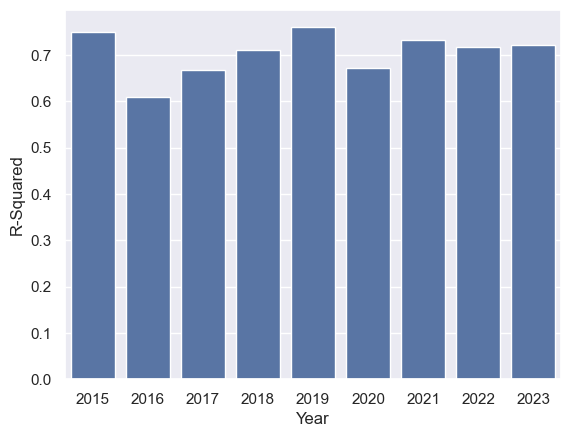

In [15]:
Y=[0.7486218957071185, 0.6090225953061896, 0.66647921560128, 0.7107608088160247, 0.7597260059076084, 0.6726654186518781, 0.732747771295933, 0.717120681914623, 0.7224616427391601]
X=[2015, 2016, 2017,2018,2019,2020,2021,2022,2023]
ax = sns.barplot(x=X, y=Y)
ax.set(xlabel='Year', ylabel='R-Squared')
np.mean(Y)

[Text(0.5, 0, 'Year'), Text(0, 0.5, 'RMSE')]

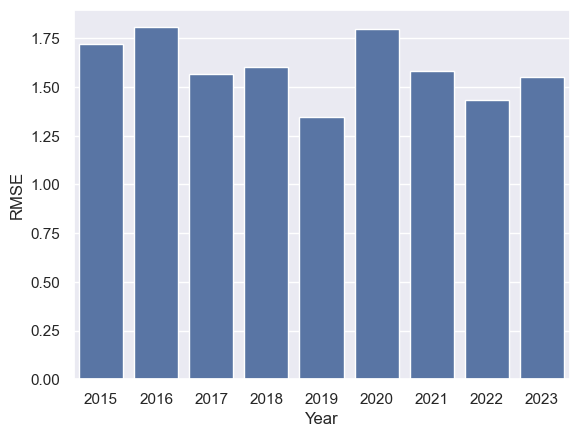

In [12]:
Y=[1.7217704120455257, 1.8068038516978104, 1.5677692305222397, 1.604455874472125, 1.348438508160914, 1.7996464625505404
  ,1.5847816362876441, 1.4350743568281226, 1.5502362366289015]
X=[2015, 2016, 2017,2018,2019,2020,2021,2022,2023]
ax = sns.barplot(x=X, y=Y)
ax.set(xlabel='Year', ylabel='RMSE')

In [13]:
np.mean(Y)

1.6021085076882027